# Prozesssimulation (Bachelor)
## Übung 5: Modellierung biochemischer Systeme am Beispiel des ADM1
### Bausteine des ADM1 modellieren

In diesem Notebook implementieren wir die in Kapitel 5 hergeleiteten Gleichungssysteme schrittweise in Python. Wir verwenden `numpy` für die Matrix-Operationen und `scipy.integrate.solve_ivp` als ODE-Löser.

**Ziele:**

1.  Die ADM1-Matrix-Notation $\frac{d\mathbf{C}}{dt} = \boldsymbol{\nu}\, \mathbf{r}$ praktisch anwenden.
2.  Die Dynamik einer einfachen Monod-Kinetik visualisieren.
3.  Die Instabilität (Akkumulation) in einer gekoppelten Prozesskaskade simulieren.
4.  Ein echtes DAE-System in Massenmatrix-Form lösen.

**Bezeichnungen (wie im Skript):** Stöchiometrie-Matrix $\boldsymbol{\nu}$ → `nu`, stöchiometrische Koeffizienten $\nu_{ij}$ → `nu_ij`, Prozessraten $r_j$ → `r_j`, Prozessratenvektor $\mathbf{r}$ → `r_vec`. In der ADM1-Originalliteratur und im Code aus Kapitel 6 heißt die Prozessrate $\rho_j$ bzw. `Rho_j` – im Skript verwenden wir $r_j$, weil $\rho$ bereits für die Dichte steht.

Zuerst importieren wir die notwendigen Bibliotheken:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Standard-Plot-Einstellungen (optional, für schönere Grafiken)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Übung 1: Monod-Kinetik eines Einzelprozesses (Batch-Reaktor)

**Code-Erklärung:**
Dieser Code löst das System aus drei ODEs für die acetoklastische Methanogenese (Skript, Abschnitt 5.5.1).
Das System $\frac{d\mathbf{C}}{dt} = \boldsymbol{\nu}\, \mathbf{r}$ wird gelöst für:

  * $\mathbf{C} = \begin{pmatrix} S \\ X \\ P \end{pmatrix}$

  * $\boldsymbol{\nu} = \begin{pmatrix} -1 / Y_{XS} \\ 1 \\ (1 - Y_{XS}) / Y_{XS} \end{pmatrix}$

  * $r_1 = \left( \mu_{max} \frac{S}{K_S + S} \right) X$

Die Funktion `adm1_step1_matrix` definiert dieses System. Sie berechnet $\mathbf{r}$ (in diesem Fall nur ein Eintrag) basierend auf dem aktuellen Zustand $\mathbf{C}$ und gibt dann das Matrix-Produkt $\boldsymbol{\nu}\, \mathbf{r}$ an den `solve_ivp`-Löser zurück.

In [2]:
# ===================================================================
# 1. PARAMETER (ADM1 - Methanogenese)
# ===================================================================
mu_max = 0.2    # max. spezifische Wachstumsrate [1/d]
K_S = 0.15      # Halbsättigungskonstante (Acetat) [kg-COD/m³]
Y_XS = 0.05     # Ertragskoeffizient [kg-COD X / kg-COD S]

# ===================================================================
# 2. STÖCHIOMETRIE-MATRIX nu (konstant)
# ===================================================================
# Berechne die stöchiometrischen Koeffizienten nu_ij
# (i = Komponente: 1 = S, 2 = X, 3 = P;  j = Prozess: 1 = Wachstum)
nu_11 = ##########
nu_21 = ##########
nu_31 = ##########

# Stöchiometrie-Matrix nu (als 3x1 Matrix)
nu = np.array([
    [nu_11],
    [nu_21],
    [nu_31]
])

print("Stöchiometrie-Matrix nu (3x1):")
print(nu)

Stöchiometrie-Matrix nu (3x1):
[[-20.]
 [  1.]
 [ 19.]]


In [3]:
# ===================================================================
# 3. DGL-FUNKTION (in Matrix-Form)
# ===================================================================
def adm1_step1_matrix(t, y):
    """
    Simuliert die Methanogenese im Batch-Reaktor.
    y ist der Komponenten-Vektor C = [S, X, P]
    """
    # 1. Komponenten aus Vektor y entpacken
    S, X, P = y

    # Numerische Stabilität sichern
    S = max(0, S)
    X = max(1e-9, X)  # Verhindert Division durch Null oder negatives Wachstum

    # 2. Prozessraten-Vektor r berechnen
    mu = ##########
    r_1 = mu * X

    r_vec = np.array([r_1])  # (Größe 1x1)

    # 3. Matrix-Multiplikation durchführen
    # dC/dt = nu @ r_vec
    # (nu ist 3x1, r_vec ist 1x1 -> dC/dt ist 3x1)
    dC_dt = nu.dot(r_vec)

    # solve_ivp erwartet einen 1D-Vektor zurück
    return dC_dt.flatten()


Starte Simulation für Übung 1...
Simulation abgeschlossen.


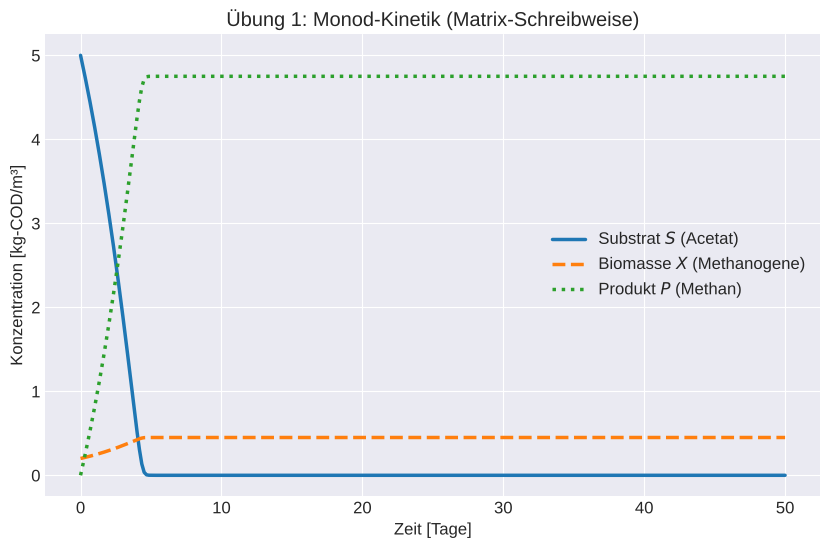

In [4]:
# ===================================================================
# 4. SIMULATION DURCHFÜHREN
# ===================================================================
S_0 = 5.0     # 5 kg-COD/m³ Acetat
X_0 = 0.2     # 0.2 kg-COD/m³ Biomasse (Animpfung)
P_0 = 0.0     # 0 kg-COD/m³ Methan am Start
y0 = [S_0, X_0, P_0]

t_span = [0, 50] # 50 Tage
t_eval = np.linspace(t_span[0], t_span[1], 300)

print("\nStarte Simulation für Übung 1...")
sol_1 = solve_ivp(adm1_step1_matrix, t_span, y0, t_eval=t_eval, method='RK45')
print("Simulation abgeschlossen.")

# ===================================================================
# 5. ERGEBNISSE PLOTTEN
# ===================================================================
plt.figure(figsize=(10, 6))
plt.title('Übung 1: Monod-Kinetik (Matrix-Schreibweise)')
plt.plot(sol_1.t, sol_1.y[0], label='Substrat $S$ (Acetat)', lw=2.5)
plt.plot(sol_1.t, sol_1.y[1], label='Biomasse $X$ (Methanogene)', lw=2.5, ls='--')
plt.plot(sol_1.t, sol_1.y[2], label='Produkt $P$ (Methan)', lw=2.5, ls=':')
plt.xlabel('Zeit [Tage]')
plt.ylabel('Konzentration [kg-COD/m³]')
plt.legend()
plt.grid(True)
plt.show()

## Übung 2: Gekoppelte Kaskade (Zwei-Prozess-Batch-Reaktor)

**Code-Erklärung:**
Dieser Code löst das System aus fünf ODEs für die Zwei-Stufen-Kaskade (Skript, Abschnitt 5.5.2).
Das System $\frac{d\mathbf{C}}{dt} = \boldsymbol{\nu}\, \mathbf{r}$ wird gelöst für:

  * $\mathbf{C} = \begin{pmatrix} S_1 \\ X_1 \\ S_2 \\ X_2 \\ P \end{pmatrix}$

  * $\boldsymbol{\nu} = \begin{pmatrix} -1/Y_{XS,1} & 0 \\ 1 & 0 \\ (1-Y_{XS,1})/Y_{XS,1} & -1/Y_{XS,2} \\ 0 & 1 \\ 0 & (1-Y_{XS,2})/Y_{XS,2} \end{pmatrix}$

  * $\mathbf{r} = \begin{pmatrix} r_1 \\ r_2 \end{pmatrix}$

Die Funktion `adm1_step2_matrix` berechnet nun den 2x1-Prozessratenvektor $\mathbf{r}$ (mit $r_1$ und $r_2$) und multipliziert ihn mit der 5x2-Stöchiometrie-Matrix $\boldsymbol{\nu}$. Wir wählen $\mu_{max,1} \gg \mu_{max,2}$, um die Akkumulation des Zwischenprodukts $S_2$ zu provozieren.

In [5]:
# ===================================================================
# 1. PARAMETER
# ===================================================================
# Prozess 1: Acidogenese (Zucker -> Acetat) - SCHNELL
mu_max_1 = 1.0    # [1/d]
K_S_1 = 0.5       # [kg-COD/m³]
Y_XS_1 = 0.15     # [kg X1 / kg S1]

# Prozess 2: Methanogenese (Acetat -> Methan) - LANGSAM
mu_max_2 = 0.2    # [1/d]
K_S_2 = 0.15      # [kg-COD/m³]
Y_XS_2 = 0.05     # [kg X2 / kg S2]

# ===================================================================
# 2. STÖCHIOMETRIE-MATRIX nu (konstant, 5x2)
# ===================================================================
# Berechne die stöchiometrischen Koeffizienten nu_ij
# (i = Komponente: 1 = S1, 2 = X1, 3 = S2, 4 = X2, 5 = P;  j = Prozess 1 oder 2)
nu_11 = -1.0 / Y_XS_1
nu_21 = 1.0
nu_31 = ##########
nu_41 = 0.0
nu_51 = 0.0

nu_12 = 0.0
nu_22 = 0.0
nu_32 = -1.0 / Y_XS_2
nu_42 = 1.0
nu_52 = ##########

nu_kaskade = np.array([
    [nu_11, nu_12],
    [nu_21, nu_22],
    [nu_31, nu_32],
    [nu_41, nu_42],
    [nu_51, nu_52]
])

print("Stöchiometrie-Matrix nu (5x2):")
print(nu_kaskade)

Stöchiometrie-Matrix nu (5x2):
[[ -6.66666667   0.        ]
 [  1.           0.        ]
 [  5.66666667 -20.        ]
 [  0.           1.        ]
 [  0.          19.        ]]


In [6]:
# ===================================================================
# 3. DGL-FUNKTION (in Matrix-Form)
# ===================================================================
def adm1_step2_matrix(t, y):
    """
    Simuliert die Zwei-Stufen-Kaskade im Batch-Reaktor.
    y ist der Komponenten-Vektor C = [S1, X1, S2, X2, P]
    """
    # 1. Komponenten aus Vektor y entpacken
    S1, X1, S2, X2, P = y

    # Numerische Stabilität sichern
    S1 = max(0, S1)
    X1 = max(1e-9, X1)
    S2 = max(0, S2)
    X2 = max(1e-9, X2)

    # 2. Prozessraten-Vektor r berechnen

    # Kinetik 1 (Acidogenese)
    mu_1 = ##########
    r_1 = mu_1 * X1

    # Kinetik 2 (Methanogenese)
    mu_2 = ##########
    r_2 = mu_2 * X2

    r_vec = np.array([r_1, r_2])  # (Größe 2x1)

    # 3. Matrix-Multiplikation durchführen
    # dC/dt = nu @ r_vec
    # (nu ist 5x2, r_vec ist 2x1 -> dC/dt ist 5x1)
    dC_dt = nu_kaskade.dot(r_vec)

    return dC_dt.flatten()  # (solve_ivp erwartet 1D-Array)


Starte Simulation für Übung 2...
Simulation abgeschlossen.


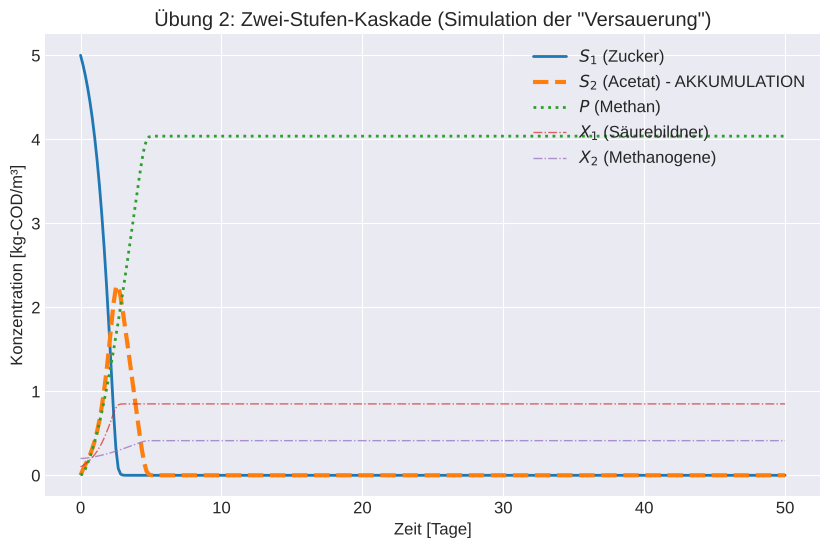

In [7]:
# ===================================================================
# 4. SIMULATION DURCHFÜHREN
# ===================================================================
S1_0 = 5.0     # 5 kg-COD/m³ Zucker (ein "Zucker-Schock")
X1_0 = 0.1     # 0.1 kg-COD/m³ Säurebildner (angeimpft)
S2_0 = 0.0     # 0 kg-COD/m³ Acetat am Start
X2_0 = 0.2     # 0.2 kg-COD/m³ Methanogene (angeimpft, wie in Schritt 1)
P_0 = 0.0      # 0 kg-COD/m³ Methan am Start
y0_kaskade = [S1_0, X1_0, S2_0, X2_0, P_0]

t_span_kaskade = [0, 50] # 50 Tage
t_eval_kaskade = np.linspace(t_span_kaskade[0], t_span_kaskade[1], 300)

print("\nStarte Simulation für Übung 2...")
# Wir verwenden einen steiferen Löser (optional, aber gut für gekoppelte Systeme)
sol_2 = solve_ivp(adm1_step2_matrix, t_span_kaskade, y0_kaskade, 
                  t_eval=t_eval_kaskade, method='Radau')
print("Simulation abgeschlossen.")

# ===================================================================
# 5. ERGEBNISSE PLOTTEN
# ===================================================================
plt.figure(figsize=(10, 6))
plt.title('Übung 2: Zwei-Stufen-Kaskade (Simulation der "Versauerung")')
plt.plot(sol_2.t, sol_2.y[0], label='$S_1$ (Zucker)', lw=2)
plt.plot(sol_2.t, sol_2.y[2], label='$S_2$ (Acetat) - AKKUMULATION', lw=3, ls='--')
plt.plot(sol_2.t, sol_2.y[4], label='$P$ (Methan)', lw=2, ls=':')
plt.plot(sol_2.t, sol_2.y[1], label='$X_1$ (Säurebildner)', lw=1, ls='-.', alpha=0.7)
plt.plot(sol_2.t, sol_2.y[3], label='$X_2$ (Methanogene)', lw=1, ls='-.', alpha=0.7)

plt.xlabel('Zeit [Tage]')
plt.ylabel('Konzentration [kg-COD/m³]')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

## Übung 3: DAE-System (Kinetik mit algebraischer Zwangsbedingung)

**Code-Erklärung:**
Dieser Code löst das DAE-System aus Skript-Abschnitt 5.5.3 für die reversible Reaktion $A \rightleftharpoons B$:

* **ODE:** $\dfrac{dC_A}{dt} = -k_+\, C_A + k_-\, C_B$ (Kinetik der Hin- und Rückreaktion)
* **AE:** $0 = C_A + C_B - C_{ges}$ (Stoffmengenerhaltung, vgl. Skript-Abschnitt 4.4) – für $C_B$ gibt es **keine** eigene ODE.

In **Massenmatrix-Form** $\mathbf{M}\, \dfrac{d\mathbf{y}}{dt} = \mathbf{f}(t, \mathbf{y})$ lautet das System:

  * $\mathbf{y} = \begin{pmatrix} C_A \\ C_B \end{pmatrix}$, $\quad \mathbf{M} = \begin{pmatrix} 1 & 0 \\ 0 & 0 \end{pmatrix}$, $\quad \mathbf{f}(t, \mathbf{y}) = \begin{pmatrix} -k_+ C_A + k_- C_B \\ C_A + C_B - C_{ges} \end{pmatrix}$

Die „0" in $M_{22}$ sagt: Die zweite Zeile ist keine Differentialgleichung, sondern eine algebraische Gleichung, die zu jedem Zeitpunkt erfüllt sein muss.

**Wichtig – Grenzen von `solve_ivp`:** `scipy.integrate.solve_ivp` kann **keine Massenmatrix** verarbeiten. Ein Argument wie `M=...` wird nur mit einer Warnung ignoriert, und der Löser rechnet dann ein falsches (reines ODE-)System. Wir lösen das DAE-System deshalb mit einem selbst geschriebenen **impliziten Euler-Verfahren** (Skript, Abschnitt 2.2.3), das die Massenmatrix direkt verwendet:
$$
\mathbf{M}\, \frac{\mathbf{y}_{n+1} - \mathbf{y}_n}{\Delta t} = \mathbf{f}(\mathbf{y}_{n+1})
$$
Weil unser System linear ist, lässt sich $\mathbf{f}(\mathbf{y}) = \mathbf{J}\, \mathbf{y} + \mathbf{b}$ schreiben. Umgestellt nach dem unbekannten $\mathbf{y}_{n+1}$ ergibt sich in jedem Zeitschritt ein lineares Gleichungssystem:
$$
\left(\mathbf{M} - \Delta t\, \mathbf{J}\right) \mathbf{y}_{n+1} = \mathbf{M}\, \mathbf{y}_n + \Delta t\, \mathbf{b}
$$
das wir mit `np.linalg.solve` lösen. Die Anfangsbedingungen müssen die algebraische Gleichung erfüllen („konsistente Anfangswerte"): Mit $C_{B,0} = 0$ gilt $C_{ges} = C_{A,0}$.

*Ausblick:* Für große, nichtlineare DAE-Systeme verwendet man spezialisierte Löser (z. B. IDA aus der SUNDIALS-Bibliothek). Alternativ kann man – wie im ADM1-Code aus Kapitel 6 – die algebraischen Gleichungen in jedem Zeitschritt separat lösen.

In [8]:
# ===================================================================
# 1. PARAMETER (Reversible Reaktion)
# ===================================================================
k_plus = 0.5     # Geschwindigkeitskonstante Hinreaktion k_+ [1/s]
k_minus = 0.1    # Geschwindigkeitskonstante Rückreaktion k_- [1/s]
K_eq = k_plus / k_minus  # Gleichgewichtskonstante K_eq = C_B/C_A im Gleichgewicht = 5.0

C_A0 = 1.0       # Anfangskonzentration A [mol/L]
C_B0 = 0.0       # Anfangskonzentration B [mol/L]
C_ges = C_A0 + C_B0  # konsistent: erfüllt die AE zum Zeitpunkt t = 0

print(f"Gleichgewichtskonstante K_eq: {K_eq}")

# ===================================================================
# 2. MASSENMATRIX M (konstant, 2x2)
# ===================================================================
# Die erste Zeile (für C_A) ist differentiell (M_11 = 1)
# Die zweite Zeile (für C_B) ist algebraisch  (M_22 = 0)
M_matrix = np.array([
    [1.0, 0.0],
    [0.0, 0.0]
])

print("\nMassenmatrix M:")
print(M_matrix)

# ===================================================================
# 3. RECHTE SEITE f(y) = J @ y + b
# ===================================================================
# Zeile 1 (ODE):  f_1 = -k_plus * C_A + k_minus * C_B
# Zeile 2 (AE):   f_2 = C_A + C_B - C_ges   (muss vom Löser auf 0 gebracht werden)
J = np.array([
    [-k_plus, k_minus],
    [1.0,     1.0]
])
b = np.array([0.0, -C_ges])

def dae_rhs(t, y):
    """Rechte Seite f(t, y) des DAE-Systems M * dy/dt = f(t, y)."""
    return J @ y + b

Gleichgewichtskonstante K_eq: 5.0

Massenmatrix M:
[[1. 0.]
 [0. 0.]]


Simulation abgeschlossen.


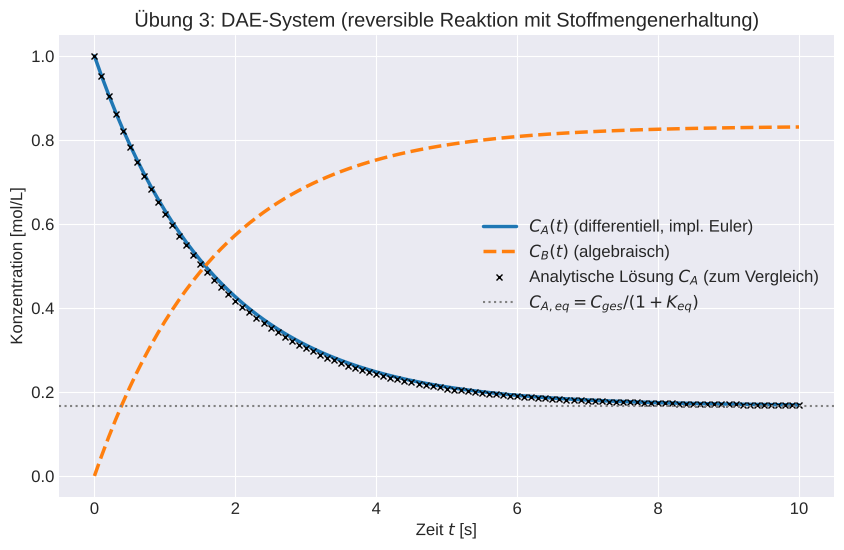

Verhältnis C_B/C_A am Ende: 4.913  (K_eq = 5.0)


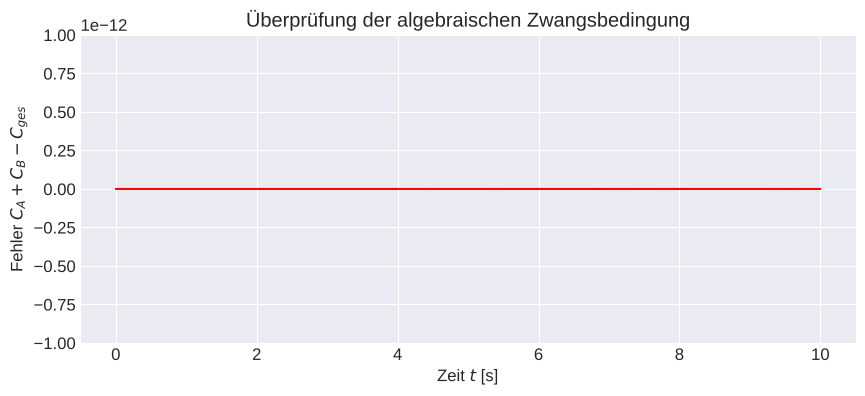

In [9]:
# ===================================================================
# 4. SIMULATION DURCHFÜHREN (implizites Euler-Verfahren mit Massenmatrix)
# ===================================================================
dt = 0.1                     # Zeitschrittweite Δt [s]
t_span_dae = [0, 10]         # 10 Sekunden
t_values = np.arange(t_span_dae[0], t_span_dae[1] + dt, dt)

y_values = np.zeros((len(t_values), 2))   # Zeilen: Zeitschritte, Spalten: [C_A, C_B]
y_values[0] = [C_A0, C_B0]                # konsistente Anfangswerte

# Systemmatrix (M - Δt*J) ist für alle Zeitschritte gleich
A_sys = M_matrix - dt * J

for n in range(len(t_values) - 1):
    rhs = M_matrix @ y_values[n] + dt * b       # rechte Seite des linearen Gleichungssystems
    y_values[n + 1] = np.linalg.solve(A_sys, rhs)

C_A_num = y_values[:, 0]
C_B_num = y_values[:, 1]
print("Simulation abgeschlossen.")

# ===================================================================
# 5. ERGEBNISSE PLOTTEN
# ===================================================================
plt.figure(figsize=(10, 6))
plt.title('Übung 3: DAE-System (reversible Reaktion mit Stoffmengenerhaltung)')
plt.plot(t_values, C_A_num, label='$C_A(t)$ (differentiell, impl. Euler)', lw=2.5)
plt.plot(t_values, C_B_num, label='$C_B(t)$ (algebraisch)', lw=2.5, ls='--')

# Analytische Lösung zum Vergleich
C_A_eq = C_ges / (1 + K_eq)   # Gleichgewichtskonzentration von A
C_A_ana = C_A_eq + (C_A0 - C_A_eq) * np.exp(-(k_plus + k_minus) * t_values)
plt.plot(t_values, C_A_ana, 'kx', label='Analytische Lösung $C_A$ (zum Vergleich)', markersize=4)
plt.axhline(C_A_eq, color='grey', ls=':', label='$C_{A,eq} = C_{ges}/(1+K_{eq})$')

plt.xlabel('Zeit $t$ [s]')
plt.ylabel('Konzentration [mol/L]')
plt.legend()
plt.grid(True)
plt.show()

print(f"Verhältnis C_B/C_A am Ende: {C_B_num[-1] / C_A_num[-1]:.3f}  (K_eq = {K_eq})")

# Plot zur Überprüfung der algebraischen Bedingung
plt.figure(figsize=(10, 4))
plt.title('Überprüfung der algebraischen Zwangsbedingung')
# Berechnet den "Fehler" der AE für jeden Zeitschritt
algebraic_error = C_A_num + C_B_num - C_ges
plt.plot(t_values, algebraic_error, 'r-')
plt.xlabel('Zeit $t$ [s]')
plt.ylabel('Fehler $C_A + C_B - C_{ges}$')
# Der Fehler sollte im Bereich der Maschinengenauigkeit (~1e-16) liegen
plt.ylim(-1e-12, 1e-12)
plt.grid(True)
plt.show()